In [9]:
!pip install -q kagglehub

import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.metrics import classification_report, confusion_matrix

print("TensorFlow version:", tf.__version__)
print("GPU available:", tf.config.list_physical_devices('GPU'))

tf.random.set_seed(42)
np.random.seed(42)

TensorFlow version: 2.20.0
GPU available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [10]:
import os

try:
    from google.colab import files
    print("Upload your kaggle.json file:")
    uploaded = files.upload()
    os.makedirs("/root/.kaggle", exist_ok=True)
    filename = next(iter(uploaded))
    with open("/root/.kaggle/kaggle.json", "wb") as f:
        f.write(uploaded[filename])
    os.chmod("/root/.kaggle/kaggle.json", 0o600)
    print("Kaggle credentials saved.")
except ImportError:
    print("Not running in Colab -- make sure ~/.kaggle/kaggle.json is already in place.")

Upload your kaggle.json file:


Saving kaggle.json to kaggle (3).json
Kaggle credentials saved.


In [11]:
import kagglehub

dataset_path = kagglehub.dataset_download("swaroopkml/cifar10-pngs-in-folders")
print("Downloaded to:", dataset_path)

import pathlib
for p in sorted(pathlib.Path(dataset_path).rglob("*"))[:30]:
    print(p)


Using Colab cache for faster access to the 'cifar10-pngs-in-folders' dataset.
Downloaded to: /kaggle/input/cifar10-pngs-in-folders
/kaggle/input/cifar10-pngs-in-folders/cifar10
/kaggle/input/cifar10-pngs-in-folders/cifar10/cifar10
/kaggle/input/cifar10-pngs-in-folders/cifar10/cifar10/test
/kaggle/input/cifar10-pngs-in-folders/cifar10/cifar10/test/airplane
/kaggle/input/cifar10-pngs-in-folders/cifar10/cifar10/test/airplane/0001.png
/kaggle/input/cifar10-pngs-in-folders/cifar10/cifar10/test/airplane/0002.png
/kaggle/input/cifar10-pngs-in-folders/cifar10/cifar10/test/airplane/0003.png
/kaggle/input/cifar10-pngs-in-folders/cifar10/cifar10/test/airplane/0004.png
/kaggle/input/cifar10-pngs-in-folders/cifar10/cifar10/test/airplane/0005.png
/kaggle/input/cifar10-pngs-in-folders/cifar10/cifar10/test/airplane/0006.png
/kaggle/input/cifar10-pngs-in-folders/cifar10/cifar10/test/airplane/0007.png
/kaggle/input/cifar10-pngs-in-folders/cifar10/cifar10/test/airplane/0008.png
/kaggle/input/cifar10-pngs

In [12]:
CLASS_NAMES = ["airplane", "automobile", "bird", "cat", "deer",
               "dog", "frog", "horse", "ship", "truck"]

TRAIN_DIR = pathlib.Path(dataset_path) / "cifar10" / "cifar10" / "train"
TEST_DIR = pathlib.Path(dataset_path) / "cifar10" / "cifar10" / "test"

from PIL import Image

def load_folder_dataset(root_dir, class_names, img_size=(32, 32)):
    """Loads a Kaggle-style `root_dir/<class_name>/*.png` layout into numpy arrays."""
    root_dir = pathlib.Path(root_dir)
    images, labels = [], []
    for label_idx, class_name in enumerate(class_names):
        class_dir = root_dir / class_name
        if not class_dir.exists():
            raise FileNotFoundError(
                f"Expected class folder not found: {class_dir}\n"
                f"Check the diagnostic listing above and update TRAIN_DIR/TEST_DIR."
            )
        for img_path in sorted(class_dir.glob("*")):
            img = Image.open(img_path).convert("RGB").resize(img_size)
            images.append(np.array(img, dtype="uint8"))
            labels.append(label_idx)
    return np.array(images, dtype="uint8"), np.array(labels, dtype="int64")

x_train, y_train = load_folder_dataset(TRAIN_DIR, CLASS_NAMES)
x_test, y_test = load_folder_dataset(TEST_DIR, CLASS_NAMES)

print("x_train:", x_train.shape, "y_train:", y_train.shape)
print("x_test :", x_test.shape,  "y_test :", y_test.shape)

x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0

x_train: (50000, 32, 32, 3) y_train: (50000,)
x_test : (10000, 32, 32, 3) y_test : (10000,)


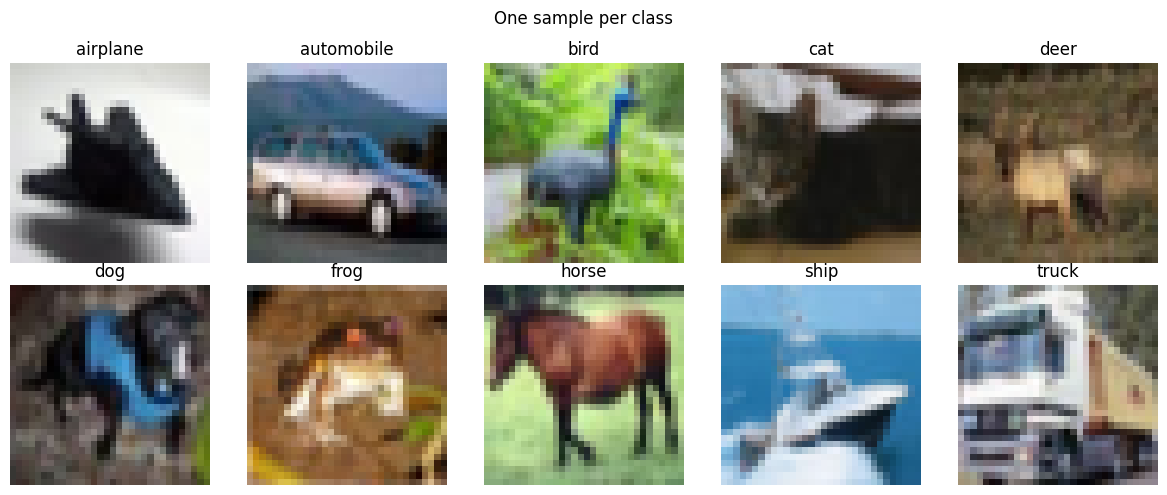

In [13]:
fig, axes = plt.subplots(2, 5, figsize=(12, 5))
for class_id in range(10):
    idx = np.where(y_train == class_id)[0][0]
    ax = axes[class_id // 5, class_id % 5]
    ax.imshow(x_train[idx])
    ax.set_title(CLASS_NAMES[class_id])
    ax.axis("off")
plt.suptitle("One sample per class")
plt.tight_layout()
plt.show()


In [14]:
def build_snapvision_cnn(input_shape=(32, 32, 3), num_classes=10):
    model = keras.Sequential([
        layers.Input(shape=input_shape),

        layers.Conv2D(32, (3, 3), padding="same", activation="relu"),
        layers.BatchNormalization(),
        layers.Conv2D(32, (3, 3), padding="same", activation="relu"),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2, 2)),
        layers.Dropout(0.25),

        layers.Conv2D(64, (3, 3), padding="same", activation="relu"),
        layers.BatchNormalization(),
        layers.Conv2D(64, (3, 3), padding="same", activation="relu"),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2, 2)),
        layers.Dropout(0.3),

        layers.Conv2D(128, (3, 3), padding="same", activation="relu"),
        layers.BatchNormalization(),
        layers.Conv2D(128, (3, 3), padding="same", activation="relu"),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2, 2)),
        layers.Dropout(0.4),

        layers.Flatten(),
        layers.Dense(256, activation="relu"),
        layers.BatchNormalization(),
        layers.Dropout(0.5),
        layers.Dense(num_classes, activation="softmax"),
    ], name="SnapVision_CNN")
    return model

model = build_snapvision_cnn()
model.summary()

Model: "SnapVision_CNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 32, 32, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 16, 16, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 8, 8, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 8, 8, 128)      │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 8, 8, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       524,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 816,938 (3.12 MB)

 Trainable params: 815,530 (3.11 MB)

 Non-trainable params: 1,408 (5.50 KB)

In [15]:
aug_datagen = ImageDataGenerator(
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.1,
    horizontal_flip=True,
)
aug_datagen.fit(x_train)

BATCH_SIZE = 64
aug_train_gen = aug_datagen.flow(x_train, y_train, batch_size=BATCH_SIZE, shuffle=True)

In [16]:
EPOCHS = 15
STEPS_PER_EPOCH = len(x_train) // BATCH_SIZE

lr_schedule = keras.optimizers.schedules.CosineDecay(
    initial_learning_rate=1e-3, decay_steps=STEPS_PER_EPOCH * EPOCHS
)

def make_optimizer(name="adam"):
    if name == "adam":
        return keras.optimizers.Adam(learning_rate=lr_schedule)
    elif name == "sgd_momentum":
        return keras.optimizers.SGD(learning_rate=lr_schedule, momentum=0.9)
    else:
        return keras.optimizers.SGD(learning_rate=lr_schedule)

model = build_snapvision_cnn()
model.compile(
    optimizer=make_optimizer("adam"),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)

early_stop = keras.callbacks.EarlyStopping(
    monitor="val_loss", patience=5, restore_best_weights=True
)

history = model.fit(
    aug_train_gen,
    steps_per_epoch=STEPS_PER_EPOCH,
    epochs=EPOCHS,
    validation_data=(x_test, y_test),
    callbacks=[early_stop],
)

Epoch 1/15
781/781 ━━━━━━━━━━━━━━━━━━━━ 60s 59ms/step - accuracy: 0.3969 - loss: 1.7631 - val_accuracy: 0.5269 - val_loss: 1.3593
Epoch 2/15
  1/781 ━━━━━━━━━━━━━━━━━━━━ 12s 16ms/step - accuracy: 0.5781 - loss: 1.3663

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/epoch_iterator.py:116: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


781/781 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.5781 - loss: 1.3663 - val_accuracy: 0.5224 - val_loss: 1.3638
Epoch 3/15
781/781 ━━━━━━━━━━━━━━━━━━━━ 36s 46ms/step - accuracy: 0.5529 - loss: 1.2509 - val_accuracy: 0.6328 - val_loss: 1.0565
Epoch 4/15
781/781 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.6250 - loss: 1.1353 - val_accuracy: 0.6256 - val_loss: 1.0811
Epoch 5/15
781/781 ━━━━━━━━━━━━━━━━━━━━ 40s 47ms/step - accuracy: 0.6222 - loss: 1.0685 - val_accuracy: 0.6077 - val_loss: 1.2079
Epoch 6/15
781/781 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.7031 - loss: 0.9604 - val_accuracy: 0.6100 - val_loss: 1.1937
Epoch 7/15
781/781 ━━━━━━━━━━━━━━━━━━━━ 36s 46ms/step - accuracy: 0.6642 - loss: 0.9580 - val_accuracy: 0.7166 - val_loss: 0.8254
Epoch 8/15
781/781 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.5781 - loss: 0.8926 - val_accuracy: 0.7187 - val_loss: 0.8188
Epoch 9/15
781/781 ━━━━━━━━━━━━━━━━━━━━ 35s 45ms/step - accuracy: 0.6911 - loss: 0.8836 - val_accuracy: 0.681

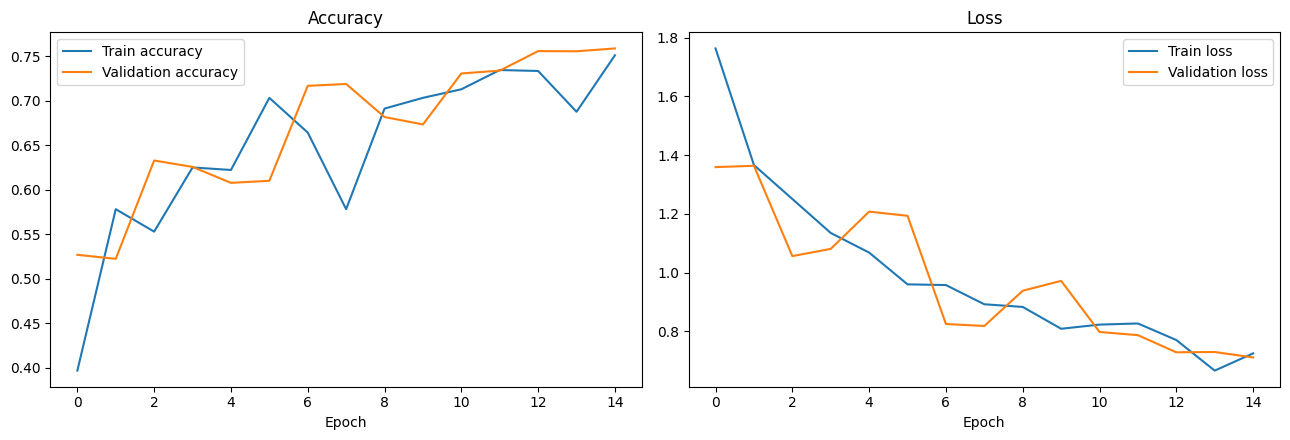

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

axes[0].plot(history.history["accuracy"], label="Train accuracy")
axes[0].plot(history.history["val_accuracy"], label="Validation accuracy")
axes[0].set_title("Accuracy")
axes[0].set_xlabel("Epoch")
axes[0].legend()

axes[1].plot(history.history["loss"], label="Train loss")
axes[1].plot(history.history["val_loss"], label="Validation loss")
axes[1].set_title("Loss")
axes[1].set_xlabel("Epoch")
axes[1].legend()

plt.tight_layout()
plt.show()

In [18]:
test_loss, test_acc = model.evaluate(x_test, y_test, verbose=0)
print(f"Test accuracy: {test_acc*100:.2f}%")
print(f"Test loss:     {test_loss:.4f}")

y_pred_probs = model.predict(x_test, verbose=0)
y_pred = np.argmax(y_pred_probs, axis=1)

print("\nClassification report:\n")
print(classification_report(y_test, y_pred, target_names=CLASS_NAMES))

Test accuracy: 75.86%
Test loss:     0.7118

Classification report:

              precision    recall  f1-score   support

    airplane       0.81      0.80      0.80      1000
  automobile       0.85      0.94      0.89      1000
        bird       0.77      0.58      0.66      1000
         cat       0.79      0.38      0.51      1000
        deer       0.78      0.66      0.72      1000
         dog       0.77      0.64      0.70      1000
        frog       0.54      0.96      0.69      1000
       horse       0.73      0.89      0.80      1000
        ship       0.94      0.81      0.87      1000
       truck       0.83      0.90      0.86      1000

    accuracy                           0.76     10000
   macro avg       0.78      0.76      0.75     10000
weighted avg       0.78      0.76      0.75     10000



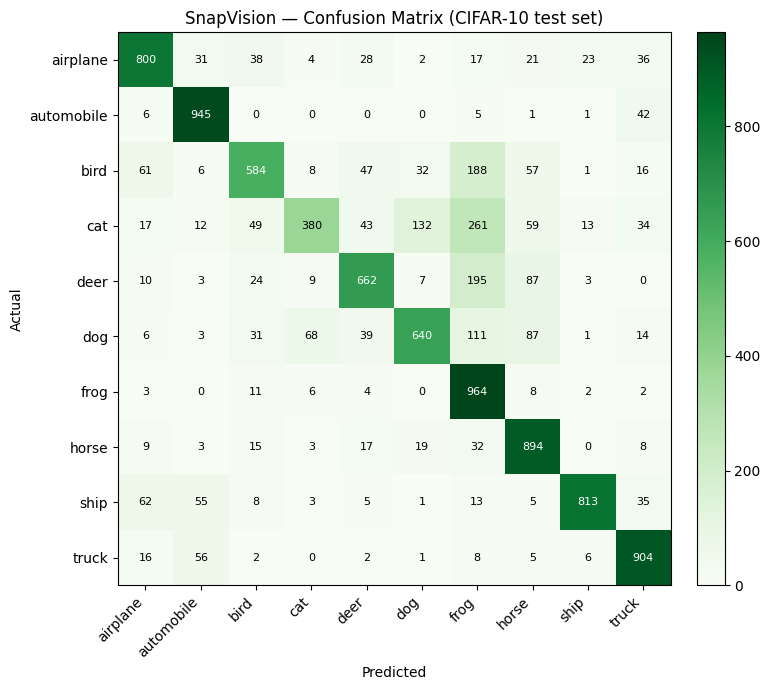

In [19]:
cm = confusion_matrix(y_test, y_pred)

fig, ax = plt.subplots(figsize=(8, 7))
im = ax.imshow(cm, cmap="Greens")
ax.set_xticks(range(10)); ax.set_xticklabels(CLASS_NAMES, rotation=45, ha="right")
ax.set_yticks(range(10)); ax.set_yticklabels(CLASS_NAMES)
ax.set_xlabel("Predicted"); ax.set_ylabel("Actual")
ax.set_title("SnapVision — Confusion Matrix (CIFAR-10 test set)")

for i in range(10):
    for j in range(10):
        ax.text(j, i, cm[i, j], ha="center", va="center",
                color="white" if cm[i, j] > cm.max() / 2 else "black", fontsize=8)

plt.colorbar(im, fraction=0.046, pad=0.04)
plt.tight_layout()
plt.show()

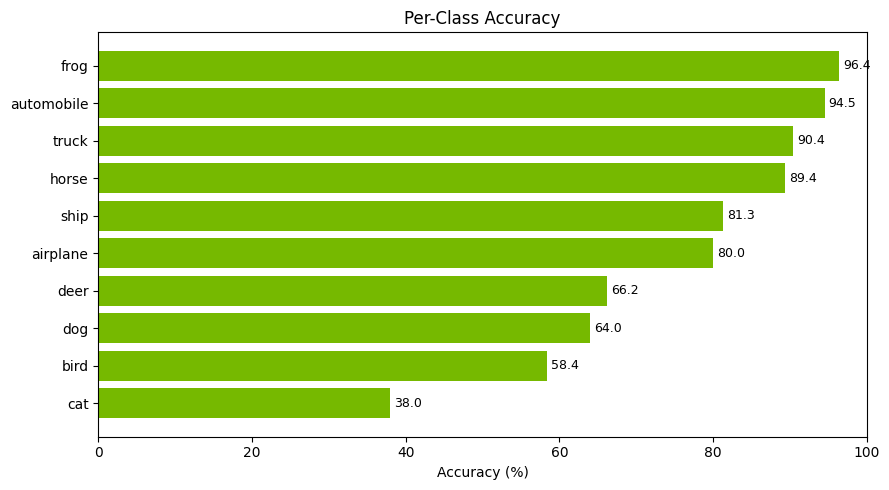

In [20]:
per_class_acc = cm.diagonal() / cm.sum(axis=1) * 100
order = np.argsort(per_class_acc)

plt.figure(figsize=(9, 5))
plt.barh(np.array(CLASS_NAMES)[order], per_class_acc[order], color="#76B900")
plt.xlabel("Accuracy (%)")
plt.title("Per-Class Accuracy")
for i, v in enumerate(per_class_acc[order]):
    plt.text(v + 0.5, i, f"{v:.1f}", va="center", fontsize=9)
plt.xlim(0, 100)
plt.tight_layout()
plt.show()

In [21]:
import json

model.save("snapvision_model.keras")

with open("class_names.json", "w") as f:
    json.dump(CLASS_NAMES, f)

print("Saved snapvision_model.keras and class_names.json")
print("Now run:  streamlit run app.py")

Saved snapvision_model.keras and class_names.json
Now run:  streamlit run app.py
